In [ ]:
!pip install numpy pandas

Distribusi kelas sebelum split:
label_encoded
0    33.333333
2    33.333333
1    33.333333
Name: proportion, dtype: float64

Jumlah data train: 2400, test: 600


/tmp/ipython-input-3977101647.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


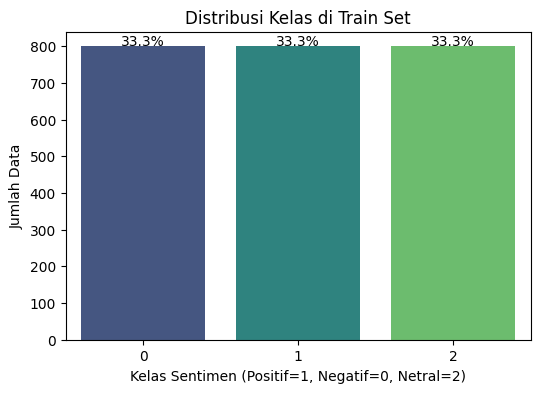

/tmp/ipython-input-3977101647.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


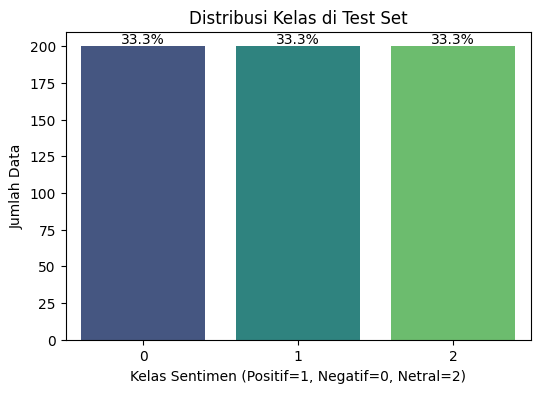


✅ Data berhasil difilter, diencode, dibagi ke dataset_train.xlsx & dataset_test.xlsx, dan divisualisasikan


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Load dataset ===
df = pd.read_excel("dataset_full_with_label.xlsx")

# === 2. Filter hanya data berlabel ===
df_labeled = df.dropna(subset=["sentiment_manual"]).copy()

# === 3. Encode label ===
label_map = {"positif": 1, "negatif": 0, "netral": 2}
df_labeled["label_encoded"] = df_labeled["sentiment_manual"].map(label_map)

print("Distribusi kelas sebelum split:")
print(df_labeled["label_encoded"].value_counts(normalize=True) * 100)

# === 4. Split train/test (80:20) dengan stratifikasi ===
train_df, test_df = train_test_split(
    df_labeled,
    test_size=0.2,
    random_state=42,
    stratify=df_labeled["label_encoded"]
)

print(f"\nJumlah data train: {len(train_df)}, test: {len(test_df)}")

# === 5. Visualisasi distribusi kelas ===
def plot_distribution(data, title):
    counts = data["label_encoded"].value_counts()
    percentages = data["label_encoded"].value_counts(normalize=True) * 100

    plt.figure(figsize=(6,4))
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")

    # Tambahkan persentase di atas bar
    for i, val in enumerate(counts.values):
        plt.text(i, val + 2, f"{percentages.iloc[i]:.1f}%", ha='center', fontsize=10)

    plt.title(title)
    plt.xlabel("Kelas Sentimen (Positif=1, Negatif=0, Netral=2)")
    plt.ylabel("Jumlah Data")
    plt.show()

# Plot distribusi train & test
plot_distribution(train_df, "Distribusi Kelas di Train Set")
plot_distribution(test_df, "Distribusi Kelas di Test Set")

# === 6. Simpan hasil split ===
train_df.to_excel("dataset_train.xlsx", index=False)
test_df.to_excel("dataset_test.xlsx", index=False)

print("\n✅ Data berhasil difilter, diencode, dibagi ke dataset_train.xlsx & dataset_test.xlsx, dan divisualisasikan")
